# Combined mmFall + TI IWR6843 Datasets — Data Concatenation & Preprocessing Pipeline

This notebook merges the preprocessed feature arrays of **mmFall** ($N=1,182$) and **TI IWR6843** ($N=728$) into a unified multi-frequency, multi-sensor benchmark of **1,910 balanced motion clips** (955 Fall : 955 ADL).

In [1]:
from pathlib import Path
import numpy as np

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

X_mmfall = np.load(preproc_dir / "X_mmfall_clean_balanced.npy")
y_mmfall = np.load(preproc_dir / "y_mmfall_clean_balanced.npy")

X_ti = np.load(preproc_dir / "X_ti_clean_balanced.npy")
y_ti = np.load(preproc_dir / "y_ti_clean_balanced.npy")

# Concatenate
X_combined = np.concatenate([X_mmfall, X_ti], axis=0)
y_combined = np.concatenate([y_mmfall, y_ti], axis=0)

# Deterministic shuffle
np.random.seed(42)
perm = np.random.permutation(len(y_combined))
X_combined = X_combined[perm]
y_combined = y_combined[perm]

print(f"Unified Combined Feature Tensor: {X_combined.shape} (Samples x Frames x Points x Channels)")
print(f"Class Distribution: {np.bincount(y_combined.astype(int))} (0 = ADL, 1 = Fall)")

# Save combined tensors
np.save(preproc_dir / "X_combined_clean_balanced.npy", X_combined)
np.save(preproc_dir / "y_combined_clean_balanced.npy", y_combined)
print("Saved unified combined tensors to datasets/preprocessed/")

Unified Combined Feature Tensor: (1910, 10, 64, 4) (Samples x Frames x Points x Channels)
Class Distribution: [955 955] (0 = ADL, 1 = Fall)
Saved unified combined tensors to datasets/preprocessed/


## 1.1 Cross-Sensor Point Cloud Standardization (Algorithm 1 Verification)

Both mmFall (77 GHz) and TI IWR6843 (60 GHz) feature arrays share the standardized format of **$N=64$ points per frame** derived via Algorithm 1.
Below, we visualize a sample frame from each sensor side-by-side to verify spatial alignment and uniform point count.

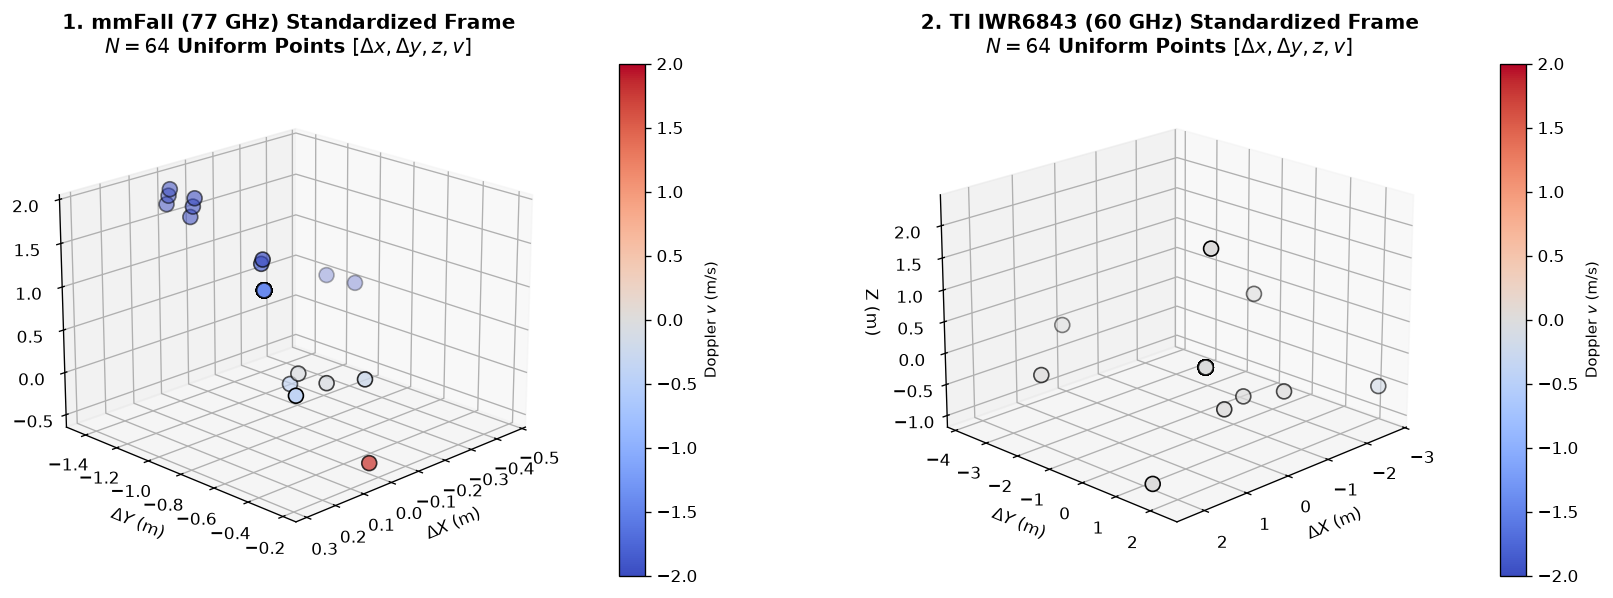

Verified both sensors output identical tensor dimensions: (64, 4) vs. (64, 4)


In [2]:
# Side-by-Side Verification of Standardized N=64 Frames from Both Sensors
import matplotlib.pyplot as plt

# Take sample frame from mmFall (Shape: [10, 64, 4]) and TI (Shape: [10, 64, 4])
mmfall_frame = X_mmfall[0, 5]  # Clip 0, Frame 5
ti_frame = X_ti[0, 5]          # Clip 0, Frame 5

fig = plt.figure(figsize=(16, 5), dpi=120)

# Subplot 1: mmFall 77 GHz standardized 64 points
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(mmfall_frame[:, 0], mmfall_frame[:, 1], mmfall_frame[:, 2], 
                  c=mmfall_frame[:, 3], cmap='coolwarm', s=80, edgecolors='black', vmin=-2, vmax=2)
ax1.set_title(f'1. mmFall (77 GHz) Standardized Frame\n$N = {len(mmfall_frame)}$ Uniform Points $[\\Delta x, \\Delta y, z, v]$', fontsize=12, fontweight='bold')
ax1.set_xlabel('$\\Delta X$ (m)'); ax1.set_ylabel('$\\Delta Y$ (m)'); ax1.set_zlabel('Z (m)')
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.03, pad=0.08)
cbar1.set_label('Doppler $v$ (m/s)', fontsize=9)
ax1.view_init(elev=20, azim=45)

# Subplot 2: TI IWR6843 60 GHz standardized 64 points
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(ti_frame[:, 0], ti_frame[:, 1], ti_frame[:, 2], 
                  c=ti_frame[:, 3], cmap='coolwarm', s=80, edgecolors='black', vmin=-2, vmax=2)
ax2.set_title(f'2. TI IWR6843 (60 GHz) Standardized Frame\n$N = {len(ti_frame)}$ Uniform Points $[\\Delta x, \\Delta y, z, v]$', fontsize=12, fontweight='bold')
ax2.set_xlabel('$\\Delta X$ (m)'); ax2.set_ylabel('$\\Delta Y$ (m)'); ax2.set_zlabel('Z (m)')
cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.03, pad=0.08)
cbar2.set_label('Doppler $v$ (m/s)', fontsize=9)
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()
print(f"Verified both sensors output identical tensor dimensions: {mmfall_frame.shape} vs. {ti_frame.shape}")